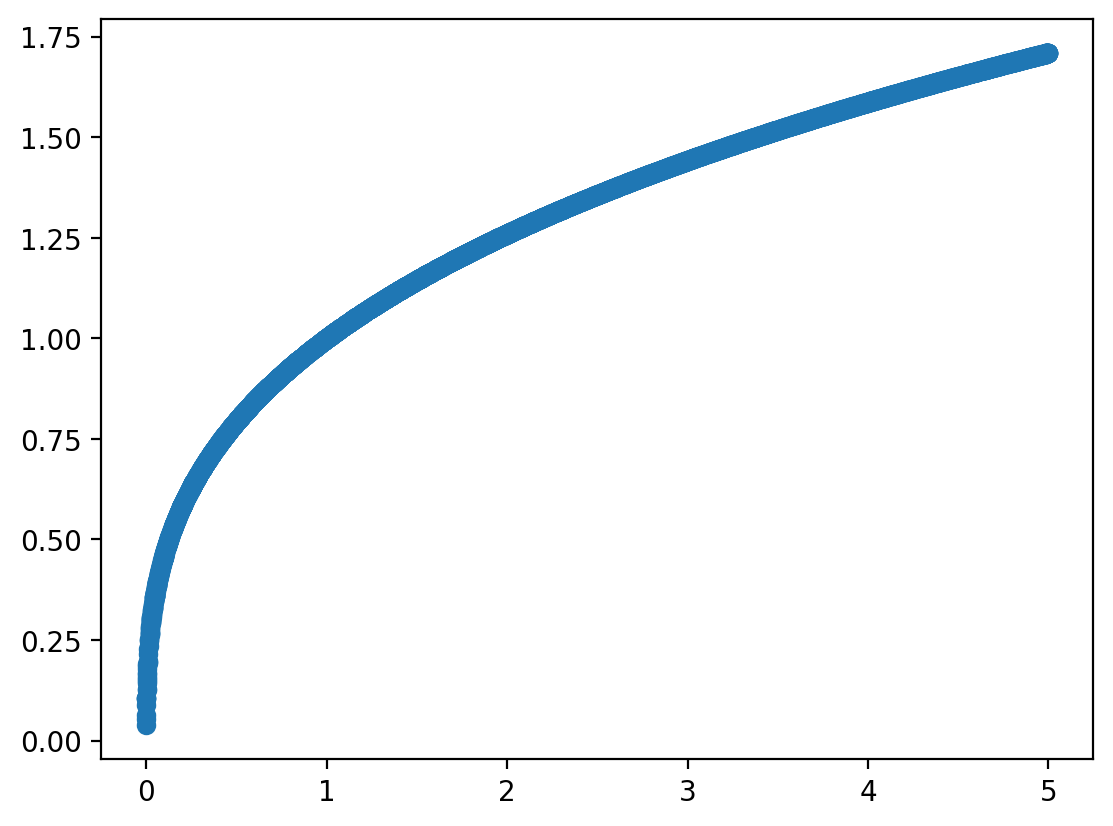

In [1]:
import numpy as np

rng = np.random.RandomState(42)

X = 5 * rng.rand(10000, 1)

y = (X ** (1/3)).ravel()
X_plot = np.linspace(0, 5, 100000)[:, None]

plt.plot(X, y, 'o')

In [5]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

train_size = 10000

svr = GridSearchCV(
    SVR(kernel="rbf", gamma=0.1),
    param_grid={"C": [1e0, 1e1, 1e2, 1e3], "gamma": np.logspace(-2, 2, 5)},
)

kr = GridSearchCV(
    KernelRidge(kernel="rbf", gamma=0.1),
    param_grid={"alpha": [1e0, 0.1, 1e-2, 1e-3], "gamma": np.logspace(-2, 2, 5)},
)

In [6]:
import time

t0 = time.time()
svr.fit(X[:train_size], y[:train_size])
svr_fit = time.time() - t0
print(f"Best SVR with params: {svr.best_params_} and R2 score: {svr.best_score_:.3f}")
print("SVR complexity and bandwidth selected and model fitted in %.3f s" % svr_fit)

t0 = time.time()
kr.fit(X[:train_size], y[:train_size])
kr_fit = time.time() - t0
print(f"Best KRR with params: {kr.best_params_} and R2 score: {kr.best_score_:.3f}")
print("KRR complexity and bandwidth selected and model fitted in %.3f s" % kr_fit)

sv_ratio = svr.best_estimator_.support_.shape[0] / train_size
print("Support vector ratio: %.3f" % sv_ratio)

t0 = time.time()
y_svr = svr.predict(X_plot)
svr_predict = time.time() - t0
print("SVR prediction for %d inputs in %.3f s" % (X_plot.shape[0], svr_predict))

t0 = time.time()
y_kr = kr.predict(X_plot)
kr_predict = time.time() - t0
print("KRR prediction for %d inputs in %.3f s" % (X_plot.shape[0], kr_predict))

Best SVR with params: {'C': 1.0, 'gamma': 0.1} and R2 score: 0.956
SVR complexity and bandwidth selected and model fitted in 20.334 s
Best KRR with params: {'alpha': 0.001, 'gamma': 100.0} and R2 score: 1.000
KRR complexity and bandwidth selected and model fitted in 756.290 s
Support vector ratio: 0.007
SVR prediction for 100000 inputs in 0.213 s
KRR prediction for 100000 inputs in 23.508 s


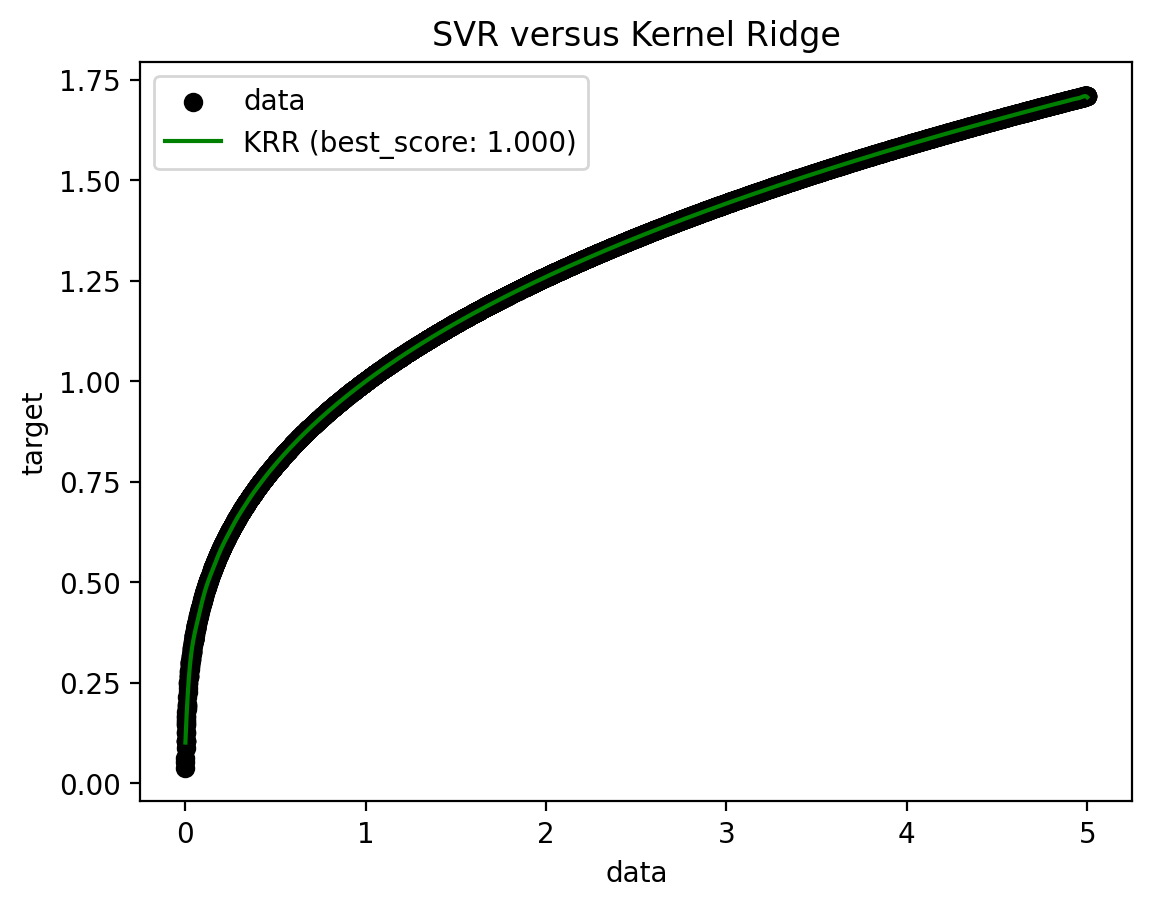

In [7]:
import matplotlib.pyplot as plt

sv_ind = svr.best_estimator_.support_
plt.scatter(
    X[:train_size], y[:train_size], c="k", label="data", zorder=1, edgecolors=(0, 0, 0)
)
plt.plot(X_plot, y_kr, c="g", label="KRR (best_score: %.3f)" % (kr.best_score_))
plt.xlabel("data")
plt.ylabel("target")
plt.title("SVR versus Kernel Ridge")
_ = plt.legend()